# Fetching Stock Market Data using yFinance

In [1]:
import yfinance as yf
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # To customize dates in plotting

### 1. Download stock data for the largest and most regulated banks in the US

**National Banks**
- Bank of America (BAC), Citigroup Inc. (C), Wells Fargo & Company (WFC), U.S. Bancorp (USB), PNC Financial Services Group Inc. (PNC), JPMorgan Chase & Co. (JPM), Capital One Financial Corporation (COF), American Express Company (AXP), Discover Financial Services (DFS), Charles Schwab Corporation (SCHW)

**Regional Banks**
- Regions Financial Corporation (RF), Huntington Bancshares Incorporated (HBAN), Fifth Third Bancorp (FITB), KeyCorp (KEY), M&T Bank Corporation (MTB), Comerica Incorporated (CMA), Citizens Financial Group Inc. (CFG), Cullen/Frost Bankers Inc. (CFR), First Horizon Corporation (FHN), Webster Financial Corporation (WBS), SouthState Corporation (SSB), Trustmark Corporation (TRMK), Zions Bancorporation (ZION), Texas Capital Bancshares Inc. (TCBI), Pinnacle Financial Partners Inc. (PNFP), Old National Bancorp (ONB), BOK Financial Corporation (BOKF), Fulton Financial Corporation (FULT), BancFirst Corporation (BANF), Valley National Bancorp (VLY), WesBanco Inc. (WSBC), Wintrust Financial Corporation (WTFC), ServisFirst Bancshares Inc. (SFBS), Home BancShares Inc. (HOMB), Hilltop Holdings Inc. (HTH), Glacier Bancorp Inc. (GBCI), United Bankshares Inc. (UBSI), Prosperity Bancshares Inc. (PB), Capitol Federal Financial Inc. (CFFN), First Financial Bankshares Inc. (FFIN), Customers Bancorp Inc. (CUBI), The Bancorp Inc. (TBBK), Meta Financial Group Inc. (CASH), Bank of N.T. Butterfield & Son Limited (NTB), East West Bancorp Inc. (EWBC), Western Alliance Bancorporation (WAL), Blue Ridge Bankshares Inc. (BRBS), Bar Harbor Bankshares Inc. (BHB), Berkshire Hills Bancorp Inc. (BHLB), Cadence Bank (CADE), Amerant Bancorp Inc. (AMTB), Ameris Bancorp (ABCB), Associated Banc-Corp (ASB), Atlantic Union Bankshares Corporation (AUB), Bank of Hawaii Corporation (BOH), BankUnited Inc. (BKU), and Banc of California Inc. (BANC).

**Online-only Banks**
- Ally Financial Inc. (ALLY), Axos Financial Inc. (AX), Synchrony Financial (SYF), Meta Financial Group Inc. (CASH), and The Bancorp Inc. (TBBK)

In [116]:
# Mapping of company names to their stock ticker symbols
tickers = {
    "Ally Financial Inc.": "ALLY",
    "Amerant Bancorp Inc.": "AMTB",
    "Ameris Bancorp": "ABCB",
    "Associated Banc-Corp": "ASB",
    "Atlantic Union Bankshares Corporation": "AUB",
    "Axos Financial Inc.": "AX",
    "Banc of California Inc.": "BANC",
    "Bank of New York Mellon Corporation": "BK",
    "Bank of America": "BAC",
    "Bank of Hawaii Corporation": "BOH",
    "BankUnited Inc.": "BKU",
    "Bar Harbor Bankshares Inc.": "BHB",
    "Berkshire Hills Bancorp Inc.": "BHLB",
    "Blue Ridge Bankshares Inc.": "BRBS",
    "Cadence Bank": "CADE",
    "Capital One Financial Corporation": "COF",
    "Citigroup Inc.": "C",
    "Citizens Financial Group Inc.": "CFG",
    "Comerica Incorporated": "CMA",
    "Cullen/Frost Bankers Inc.": "CFR",
    "F.N.B. Corporation": "FNB",
    "FB Financial Corporation": "FBK",
    "Fifth Third Bancorp": "FITB",
    "Huntington Bancshares Incorporated": "HBAN",
    "KeyCorp": "KEY",
    "M&T Bank Corporation": "MTB",
    "PNC Financial Services Group Inc.": "PNC",
    "Regions Financial Corporation": "RF",
    "State Street Corporation": "STT",
    "Synchrony Financial": "SYF",
    "U.S. Bancorp": "USB",
    "Wells Fargo & Company": "WFC",
    "Charles Schwab Corporation": "SCHW",
    "American Express Company": "AXP",
    "Discover Financial Services": "DFS",
    "Bank of N.T. Butterfield & Son Limited": "NTB",
    "East West Bancorp Inc.": "EWBC",
    "Western Alliance Bancorporation": "WAL",
    "SouthState Corporation": "SSB",
    "Webster Financial Corporation": "WBS",
    "First Horizon Corporation": "FHN",
    "Pinnacle Financial Partners Inc.": "PNFP",
    "Home BancShares Inc.": "HOMB",
    "Hilltop Holdings Inc.": "HTH",
    "Glacier Bancorp Inc.": "GBCI",
    "BOK Financial Corporation": "BOKF",
    "Zions Bancorporation": "ZION",
    "Texas Capital Bancshares Inc.": "TCBI",
    "Civista Bancshares Inc.": "CIVB",
    "C&F Financial Corporation": "CFFI",
    "BancFirst Corporation": "BANF",
    "Fulton Financial Corporation": "FULT",
    "Old National Bancorp": "ONB",
    "Prosperity Bancshares Inc.": "PB",
    "United Bankshares Inc.": "UBSI",
    "Valley National Bancorp": "VLY",
    "Trustmark Corporation": "TRMK",
    "Meta Financial Group Inc.": "CASH",
    "Customers Bancorp Inc.": "CUBI",
    "Capitol Federal Financial Inc.": "CFFN",
    "First Financial Bankshares Inc.": "FFIN",
    "ServisFirst Bancshares Inc.": "SFBS",
    "The Bancorp Inc.": "TBBK",
    "WesBanco Inc.": "WSBC",
    "Wintrust Financial Corporation": "WTFC"
}

# Download historical stock data (e.g., past 1 year)
data = yf.download(list(tickers.values()), start="2023-2-17", end="2023-04-01", group_by='ticker')

# Optional: print the closing prices for all stocks
closing_prices = {name: data[ticker]['Close'] for name, ticker in tickers.items()}
df_closing = pd.DataFrame(closing_prices)


[*********************100%***********************]  65 of 65 completed


In [118]:
df_closing.head()

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-17,28.603054,28.016195,47.438038,21.413456,34.900051,50.240002,16.861067,48.087330,33.027531,66.984222,...,10.950442,27.346952,51.396706,32.060001,7.512531,36.287521,71.007286,37.160000,33.330986,88.740837
2023-02-21,27.451563,27.554871,46.070755,21.017740,34.250023,47.330002,16.767441,47.088234,32.252060,65.820343,...,10.629421,27.365398,50.444359,30.780001,7.381040,35.517475,70.288589,34.389999,32.914352,87.781891
2023-02-22,27.691072,27.670202,45.789547,20.855862,34.387352,47.529999,16.617649,46.836124,32.037167,65.635201,...,10.486744,27.420715,50.732044,30.660000,7.337209,35.441418,70.049019,34.080002,32.781384,87.551758
2023-02-23,28.087189,27.977751,46.827129,21.008749,34.460594,47.709999,16.608288,46.957520,32.009140,66.128944,...,10.468908,27.761862,50.930454,30.920000,7.389806,35.650562,71.055199,34.119999,32.914352,87.772308
2023-02-24,27.838465,27.593311,46.565308,21.206606,34.359886,47.599998,16.308702,47.116245,31.962425,66.234756,...,10.442157,27.927824,50.662601,31.150000,7.381040,35.308323,70.997688,34.299999,32.772514,89.038109


In [120]:
# Retrieve S&P500 index
sp500 = yf.download("^GSPC", start="2023-02-17", end="2023-04-01")
sp500_close = sp500['Close']

[*********************100%***********************]  1 of 1 completed


In [122]:
sp500_close.head(3)

Ticker,^GSPC
Date,
2023-02-17,4079.090088
2023-02-21,3997.340088
2023-02-22,3991.050049


In [124]:
# Export the data to csv format
merged_df = pd.concat([df_closing, sp500_close], axis=1, join='outer')  # 'outer' keeps all dates
merged_df.to_csv("bank_stocks_close.csv")

### 2. Compute the cumulative abnormal returns (CAR) around the Silicon Valley Bank collapse

To compute **Cumulative Abnormal Returns (CARs)** over event windows like (–3, +3), (–5, +5) and (-10, 10) you'll need:

- **Stock returns** (for each firm).
- **Market returns** (e.g. S&P500 index)
- **Expected/normal returns**, usually estimated using a **market model**.
- The **abnormal return**: actual return minus expected return.
- The **event date** for each firm. In this case, it is <span style="color:red">March 10, 2023</span>.
- The **cumulative sum** of abnormal returns within the window.

#### 2.1 Compute daily returns

In [129]:
returns_stocks = df_closing.pct_change().dropna()
returns_stocks.head(7)

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-21,-0.040258,-0.016466,-0.028823,-0.018480,-0.018625,-0.057922,-0.005553,-0.020777,-0.023480,-0.017375,...,-0.029316,0.000675,-0.018529,-0.039925,-0.017503,-0.021221,-0.010121,-0.074543,-0.012500,-0.010806
2023-02-22,0.008725,0.004186,-0.006104,-0.007702,0.004010,0.004226,-0.008933,-0.005354,-0.006663,-0.002813,...,-0.013423,0.002021,0.005703,-0.003899,-0.005938,-0.002141,-0.003408,-0.009014,-0.004040,-0.002622
2023-02-23,0.014305,0.011115,0.022660,0.007331,0.002130,0.003787,-0.000563,0.002592,-0.000875,0.007523,...,-0.001701,0.012441,0.003911,0.008480,0.007168,0.005901,0.014364,0.001174,0.004056,0.002519
2023-02-24,-0.008855,-0.013741,-0.005591,0.009418,-0.002922,-0.002306,-0.018038,0.003380,-0.001459,0.001600,...,-0.002555,0.005978,-0.005259,0.007439,-0.001186,-0.009600,-0.000809,0.005276,-0.004309,0.014421
2023-02-27,-0.020185,-0.005573,0.001666,-0.002544,-0.000533,0.000210,0.010333,0.007531,0.000000,0.001881,...,-0.005124,-0.016177,0.009203,-0.005779,-0.007126,-0.004577,0.002429,0.006997,-0.010820,0.006247
2023-02-28,0.014860,-0.005254,-0.004782,-0.006864,-0.001333,-0.004621,-0.002841,0.000787,0.002631,0.004024,...,-0.006009,-0.005749,-0.010283,-0.005489,0.003589,-0.007844,-0.004309,0.001448,-0.011485,-0.013914
2023-03-01,0.000666,0.001409,-0.002716,0.006048,-0.001335,-0.002321,-0.013105,-0.007075,-0.004665,-0.002805,...,-0.008636,-0.004422,-0.010586,-0.004221,-0.009535,-0.009269,-0.015280,0.000289,0.000000,0.000434


In [131]:
returns_market = sp500_close.pct_change().dropna()
returns_market.head(7)

Ticker,^GSPC
Date,
2023-02-21,-0.020041
2023-02-22,-0.001574
2023-02-23,0.005329
2023-02-24,-0.010538
2023-02-27,0.003073
2023-02-28,-0.003036
2023-03-01,-0.004725


#### 2.2 Estimate expected returns (Market Model)

Use OLS regression:

$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}$

In [133]:
# Import package for statistical modeling
import statsmodels.api as sm

# Estimate alpha and beta for each stock
alpha_beta = {} # initialize
for stock in returns_stocks.columns:
    y = returns_stocks[stock]
    X = sm.add_constant(returns_market) # so that regressors include the intercept
    model = sm.OLS(y, X).fit()
    alpha_beta[stock] = model.params  # [const, beta]

#### 2.3 Compute abnormal returns

Note that $AR_{it}=R_{it}-E(R_{it})$, where $E(R_{it})$ is the predicted y-value from the market model

In [136]:
# First let's look at the values of [const, beta]
df_alpha_beta = pd.DataFrame(alpha_beta)
df_alpha_beta.head(2)

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
const,-0.006749,-0.010071,-0.009700,-0.009448,-0.002937,-0.010507,-0.012162,-0.004500,-0.007221,-0.012125,...,-0.009487,-0.006044,-0.007643,-0.017221,-0.008375,-0.006026,-0.010298,-0.009509,-0.006792,-0.008124
^GSPC,1.929474,1.524027,1.713014,1.925564,1.738253,2.504779,1.616289,1.546914,1.423514,2.231575,...,1.349291,0.812267,1.653804,2.919824,1.386550,1.737668,1.420769,2.954029,1.271322,2.255765


Calculate $E(R_{it})$

In [139]:
# Calculate the expected return
exp_return=returns_stocks.copy()

for stock in exp_return.columns:
    # Get the alpha and beta for the stock
    alpha = df_alpha_beta.loc['const', stock]   # The constant (alpha) for the stock
    beta = df_alpha_beta.loc['^GSPC', stock]  # The beta for the stock
    
    # Calculate the expected return as alpha + beta * returns_market
    exp_return[stock] = alpha + beta * returns_market

In [141]:
exp_return.head(5)

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-21,-0.045418,-0.040614,-0.044031,-0.048039,-0.037773,-0.060706,-0.044555,-0.035502,-0.035750,-0.056849,...,-0.036529,-0.022323,-0.040787,-0.075738,-0.036163,-0.040851,-0.038772,-0.068712,-0.032271,-0.053332
2023-02-22,-0.009785,-0.012469,-0.012396,-0.012478,-0.005672,-0.014448,-0.014706,-0.006934,-0.009461,-0.015637,...,-0.011611,-0.007323,-0.010245,-0.021816,-0.010557,-0.008760,-0.012533,-0.014158,-0.008792,-0.011674
2023-02-23,0.003534,-0.001949,-0.000571,0.000814,0.006327,0.002842,-0.003548,0.003745,0.000366,-0.000232,...,-0.002296,-0.001716,0.001171,-0.001660,-0.000985,0.003235,-0.002726,0.006234,-0.000016,0.003898
2023-02-24,-0.027081,-0.026130,-0.027751,-0.029739,-0.021254,-0.036901,-0.029194,-0.020800,-0.022221,-0.035641,...,-0.023706,-0.014604,-0.025070,-0.047989,-0.022986,-0.024337,-0.025269,-0.040637,-0.020188,-0.031894
2023-02-27,-0.000820,-0.005387,-0.004436,-0.003531,0.002405,-0.002810,-0.007196,0.000254,-0.002846,-0.005268,...,-0.005341,-0.003548,-0.002560,-0.008248,-0.004114,-0.000686,-0.005932,-0.000431,-0.002885,-0.001192


Then calculate $AR_{it}=R_{it}-E(R_{it})$

In [144]:
abnormal_returns = returns_stocks - exp_return
abnormal_returns.head(5)

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-21,0.005160,0.024148,0.015209,0.029559,0.019148,0.002784,0.039002,0.014725,0.012270,0.039474,...,0.007213,0.022998,0.022257,0.035813,0.018660,0.019630,0.028650,-0.005831,0.019771,0.042526
2023-02-22,0.018510,0.016654,0.006292,0.004776,0.009682,0.018674,0.005772,0.001580,0.002798,0.012824,...,-0.001812,0.009344,0.015948,0.017917,0.004618,0.006619,0.009125,0.005143,0.004752,0.009052
2023-02-23,0.010771,0.013063,0.023231,0.006517,-0.004197,0.000945,0.002985,-0.001153,-0.001241,0.007755,...,0.000596,0.014157,0.002740,0.010140,0.008154,0.002666,0.017090,-0.005060,0.004073,-0.001379
2023-02-24,0.018226,0.012389,0.022160,0.039157,0.018331,0.034596,0.011156,0.024180,0.020762,0.037241,...,0.021150,0.020582,0.019810,0.055427,0.021799,0.014737,0.024460,0.045913,0.015879,0.046316
2023-02-27,-0.019366,-0.000186,0.006102,0.000986,-0.002938,0.003020,0.017529,0.007277,0.002846,0.007149,...,0.000217,-0.012629,0.011764,0.002470,-0.003012,-0.003891,0.008361,0.007429,-0.007935,0.007439


### 3. Compute CARs for windows around the event date (March 10, 2023)

In [195]:
from datetime import timedelta

#event_date = pd.Timestamp("2023-03-08")  # SVB announcement of sale of securities (and emergency sale of US treasuries) to raise cash
event_date = pd.Timestamp("2023-03-10")  # SVB collapse date

windows = [(-3, 3), (-5, 5), (-10, 10)]
cars = {}

for start, end in windows:
    window_range = abnormal_returns.loc[event_date + timedelta(days=start): event_date + timedelta(days=end)]
    cars[(start, end)] = window_range.sum()

In [197]:
cars_df = pd.DataFrame(cars)
cars_df.head(5)

,-3,-5,-10
,3,5,10
Ally Financial Inc.,-0.127787,-0.121758,-0.102984
Amerant Bancorp Inc.,-0.054199,-0.045727,-0.086562
Ameris Bancorp,-0.085597,-0.093114,-0.116837
Associated Banc-Corp,-0.014095,-0.029019,-0.081630
Atlantic Union Bankshares Corporation,-0.071107,0.053102,-0.013490


In [199]:
# Summary statistics to get the mean
cars_df.describe().T

,,count,mean,std,min,25%,50%,75%,max
-3,3,65.0,-0.083016,0.083152,-0.529441,-0.100022,-0.063676,-0.037115,0.016653
-5,5,65.0,-0.064547,0.068940,-0.301383,-0.089486,-0.058020,-0.021089,0.062330
-10,10,65.0,-0.082017,0.065638,-0.387705,-0.099218,-0.071094,-0.041704,0.020428


##### The cumulative abnormal returns over a wider time window (-5,5) and (-10,10) are negative, whereas the CARs over the short window (-3,3) are on average close to zero.

### 4. Event study regression

Additional Python reference [here](https://lemairejean-baptiste.github.io/eventstudy/get_started.html)

In [203]:
# Load packages
# %pip install eventstudy # Install eventstudy

import eventstudy as es
import numpy as np
import matplotlib.pyplot as plt

#### 4.1 Convert data from wide to long format

The `abnormal_returns` data from above is in the **wide** format. It needs to be converted to **long** format first before we can run an event-study regression. 

To do this, we can use `pandas.melt()`

In [206]:
# Convert wide to long
abnormal_returns_long = abnormal_returns.reset_index().melt(
    id_vars='Date',
    var_name='firm',
    value_name='abnormal_return'
)

abnormal_returns_long.head(3)

,Date,firm,abnormal_return
0,2023-02-21,Ally Financial Inc.,0.005160
1,2023-02-22,Ally Financial Inc.,0.018510
2,2023-02-23,Ally Financial Inc.,0.010771


#### 4.2 Create dummies for each event time (e.g., –5 to +5)

In [209]:
# Define event date and windows
event_date = pd.Timestamp("2023-03-10")
estimation_window = 15
event_window = 5

# Get indices for windows
event_idx = returns_stocks.index.get_loc(event_date)
est_start = event_idx - estimation_window - event_window
est_end = event_idx - event_window
evt_start = event_idx
evt_end = event_idx + event_window

In [211]:
# Define relative days from the event
relative_days = list(range(-5, 6))  # from day -5 to +5

# Compute cumulative abnormal returns per firm
CARs_df = abnormal_returns.cumsum()

# Normalize: subtract CAR at day -1 for each firm
CARs_normalized = CARs_df.subtract(CARs_df.loc['2023-03-03'])

# To display what the normalized returns look like
CARs_normalized.head(12)

,Ally Financial Inc.,Amerant Bancorp Inc.,Ameris Bancorp,Associated Banc-Corp,Atlantic Union Bankshares Corporation,Axos Financial Inc.,Banc of California Inc.,Bank of New York Mellon Corporation,Bank of America,Bank of Hawaii Corporation,...,Valley National Bancorp,Trustmark Corporation,Meta Financial Group Inc.,Customers Bancorp Inc.,Capitol Federal Financial Inc.,First Financial Bankshares Inc.,ServisFirst Bancshares Inc.,The Bancorp Inc.,WesBanco Inc.,Wintrust Financial Corporation
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-21,-0.055102,-0.035560,-0.048588,-0.049651,0.003061,-0.056246,-0.051929,-0.035074,-0.036611,-0.079372,...,-0.015152,-0.030797,-0.024924,-0.097514,-0.035811,-0.001424,-0.041126,-0.065408,-0.001761,-0.036613
2023-02-22,-0.036592,-0.018906,-0.042297,-0.044875,0.012742,-0.037572,-0.046157,-0.033494,-0.033813,-0.066548,...,-0.016965,-0.021453,-0.008976,-0.079597,-0.031193,0.005195,-0.032001,-0.060265,0.002991,-0.027560
2023-02-23,-0.025821,-0.005843,-0.019066,-0.038358,0.008545,-0.036627,-0.043172,-0.034646,-0.035054,-0.058793,...,-0.016369,-0.007296,-0.006236,-0.069457,-0.023039,0.007862,-0.014911,-0.065325,0.007064,-0.028939
2023-02-24,-0.007595,0.006547,0.003094,0.000798,0.026876,-0.002032,-0.032016,-0.010466,-0.014292,-0.021552,...,0.004781,0.013286,0.013574,-0.014030,-0.001240,0.022598,0.009549,-0.019412,0.022943,0.017377
2023-02-27,-0.026961,0.006361,0.009196,0.001785,0.023938,0.000988,-0.014488,-0.003189,-0.011446,-0.014403,...,0.004998,0.000657,0.025338,-0.011560,-0.004252,0.018707,0.017910,-0.011983,0.015008,0.024816
2023-02-28,0.000506,0.015805,0.019315,0.010215,0.030819,0.014479,-0.000259,0.006793,0.002727,0.008521,...,0.012574,0.003419,0.027718,0.009037,0.011921,0.022164,0.028212,0.007942,0.014175,0.025874
2023-03-01,0.017038,0.034486,0.034394,0.034809,0.040635,0.034500,0.006435,0.011527,0.012009,0.028386,...,0.019801,0.008880,0.032589,0.035834,0.017313,0.027132,0.029943,0.031699,0.026974,0.045091
2023-03-02,0.013480,0.007685,0.014767,0.001319,0.018096,0.004653,-0.000009,-0.002234,-0.004240,0.016625,...,0.000766,0.003982,0.005897,0.012658,0.007954,0.009801,-0.002391,0.017943,0.006699,0.021031
2023-03-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [213]:
# Compute mean and optionally std across firms
mean_CAR = CARs_normalized.mean(axis=1)
std_CAR = CARs_normalized.std(axis=1)

std_CAR.loc['2023-03-03':'2023-03-17']

Date
2023-03-03    0.000000
2023-03-06    0.013771
2023-03-07    0.018030
2023-03-08    0.022239
2023-03-09    0.024425
2023-03-10    0.029939
2023-03-13    0.082133
2023-03-14    0.080522
2023-03-15    0.068940
2023-03-16    0.067542
2023-03-17    0.070026
dtype: float64

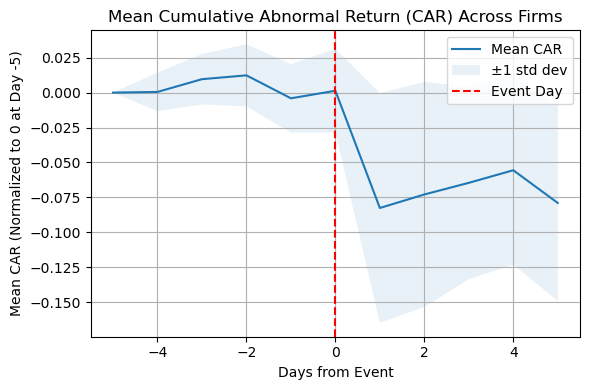

In [218]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(relative_days, mean_CAR.loc['2023-03-03':'2023-03-17'], label="Mean CAR")
plt.fill_between(relative_days, mean_CAR.loc['2023-03-03':'2023-03-17'] - std_CAR.loc['2023-03-03':'2023-03-17'], 
                 mean_CAR.loc['2023-03-03':'2023-03-17'] + std_CAR.loc['2023-03-03':'2023-03-17'], alpha=0.1, label='±1 std dev')

# Event marker at day 0
plt.axvline(x=0, color='red', linestyle='--', label='Event Day')

plt.title("Mean Cumulative Abnormal Return (CAR) Across Firms")
plt.xlabel("Days from Event")
plt.ylabel("Mean CAR (Normalized to 0 at Day -5)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()